# CSBS Cluster Analysis — Version 2: Four Composite Scores
**Author:** Toby Beevers  
**Supersedes:** `csbs_cluster_analysis.ipynb` (v1 — 26 raw variables including breach outcome)

---

## What changed from v1 and why

The original cluster analysis (v1) used 26 raw binary variables as cluster inputs, including:
- `breached` as one of the features — making cluster profiles circular when describing breach rates
- `step1–step10` as 10 separate variables — over-weighting the technical controls dimension (10×) relative to board priority (1×)
- `policy8` and `policy9` — only available in ~half the waves (47% non-null), so heavily imputed

**V2 approach:** Collapse all variables into four theoretically grounded composite scores (0–1 each), cluster on those, then describe breach outcome *post-hoc* as an outcome descriptor — not a clustering input.

| Dimension | Variables | Score |
|---|---|---|
| Board priority | `priority` (Q9) | Normalised 0–1: `(4 − priority) / 3` |
| Management | `manage1, manage2, manage3, manage4, manage6, manage7` | Proportion active: 0–6 positives ÷ 6 |
| Policy | `policy1, policy2, policy3, policy4, policy5` | Proportion active: 0–5 positives ÷ 5 |
| Controls | `step1–step10` | Proportion active: 0–10 positives ÷ 10 |

**Policy8 and policy9 are excluded** — not asked in all waves, ~47% availability. Using only `policy1–5` (100% availability).

**`breached` is excluded from clustering** — it becomes a post-hoc outcome descriptor after clusters are assigned.

This design maps directly to the five visualisation stories and to Governance Score B in Story 1.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## 2. Load survey data

Same loading pattern as v1. `PROJECT_ROOT` is derived from `Path.cwd().parent` — this notebook must be run with its kernel CWD set to the `machine learning/` directory.

In [2]:
PROJECT_ROOT = Path.cwd().parent

MISSING_CODES = [-1, -97, -98, -99]

GOVERNANCE_VARS = ['manage1', 'manage2', 'manage3', 'manage4', 'manage6', 'manage7']
POLICY_VARS     = ['policy1', 'policy2', 'policy3', 'policy4', 'policy5']  # policy8/9 excluded
CONTROLS_VARS   = ['step1', 'step2', 'step3', 'step4', 'step5',
                   'step6', 'step7', 'step8', 'step9', 'step10']

def normalise_columns(df):
    df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False).str.lower()
    return df

raw = {}
for year in range(2018, 2026):
    path = PROJECT_ROOT / 'data_raw' / f'{year}.tab'
    df = pd.read_csv(path, sep='\t', low_memory=False)
    df = normalise_columns(df)
    df['year'] = year
    raw[year] = df

print(f"Loaded {len(raw)} waves:")
for y, df in raw.items():
    print(f"  {y}: {len(df):,} rows, {df.shape[1]:,} columns")

Loaded 8 waves:
  2018: 2,088 rows, 462 columns
  2019: 2,080 rows, 462 columns
  2020: 1,900 rows, 313 columns
  2021: 2,284 rows, 421 columns
  2022: 2,157 rows, 447 columns
  2023: 3,991 rows, 568 columns
  2024: 3,434 rows, 499 columns
  2025: 3,835 rows, 528 columns


## 3. Clean and build composite scores

Cleaning is identical to v1. The key difference is that we build four composite scores (0–1) immediately after cleaning rather than passing raw binary variables to the model.

**Policy routing fix:** `policy1–5` are coded `-1` (routing) when `manage3 == 0` (no formal policy). These mean the policy does not exist — recode to `0` before the missing-code sweep.

**2025 quirks:**
- `priority` uses `997` for don't-know (not `-97`) → whitelist to `{1,2,3,4}`
- `type11` uses `-9` for missing (not `-1`) → whitelist to `{0,1}`

**Composite score logic:**
- `priority_score` — `(4 − priority) / 3` → Very high=1.0, Fairly high=0.667, Fairly low=0.333, Very low=0.0
- `manage_score` — mean of 6 binary manage indicators → proportion active (0–1)
- `policy_score` — mean of 5 binary policy indicators (policy1–5 only) → proportion active (0–1)
- `controls_score` — mean of 10 binary step indicators → proportion active (0–1)

Sanity check: unweighted breach rates should be 40–58% per wave. Values above 90% indicate the 2025 quirk filters failed.

In [3]:
def prepare_wave(df):
    df = df.copy()

    # Businesses only — sizeb is only meaningful for samptype == 1
    df = df[df['samptype'] == 1].copy()

    # Policy routing fix: -1 when manage3==0 means policy doesn't exist → 0
    if 'manage3' in df.columns:
        no_policy = df['manage3'] == 0
        for col in POLICY_VARS:
            if col in df.columns:
                df.loc[no_policy & (df[col] == -1), col] = 0

    # Standard missing codes → NaN
    df = df.replace(MISSING_CODES, np.nan)

    # priority: whitelist {1,2,3,4}; normalise to 0–1 (higher = higher priority)
    if 'priority' in df.columns:
        df['priority'] = df['priority'].where(df['priority'].isin([1, 2, 3, 4]))
        df['priority_score'] = (4 - df['priority']) / 3

    # type11: whitelist {0,1}; type11==0 → breached
    if 'type11' in df.columns:
        df['type11'] = df['type11'].where(df['type11'].isin([0, 1]))
        df['breached'] = (df['type11'] == 0).astype(float)
        df.loc[df['type11'].isna(), 'breached'] = np.nan

    # Composite scores
    manage_cols   = [c for c in GOVERNANCE_VARS if c in df.columns]
    policy_cols   = [c for c in POLICY_VARS     if c in df.columns]
    controls_cols = [c for c in CONTROLS_VARS   if c in df.columns]

    df['manage_score']   = df[manage_cols].mean(axis=1)    # proportion of 6 active
    df['policy_score']   = df[policy_cols].mean(axis=1)    # proportion of 5 active
    df['controls_score'] = df[controls_cols].mean(axis=1)  # proportion of 10 active

    return df

cleaned = {year: prepare_wave(df) for year, df in raw.items()}

print("Sanity check — breach rate per wave (expect 40–58%):")
for y, df in cleaned.items():
    breach_pct = df['breached'].mean() * 100
    print(f"  {y}: {len(df):,} businesses | breach rate {breach_pct:.1f}%")

Sanity check — breach rate per wave (expect 40–58%):
  2018: 1,519 businesses | breach rate 52.1%
  2019: 1,615 businesses | breach rate 42.1%
  2020: 1,374 businesses | breach rate 57.5%
  2021: 1,448 businesses | breach rate 47.2%
  2022: 1,265 businesses | breach rate 47.3%
  2023: 2,413 businesses | breach rate 41.2%
  2024: 2,000 businesses | breach rate 57.6%
  2025: 2,180 businesses | breach rate 53.5%


## 4. Build feature matrix

Four composite score columns are extracted alongside metadata (`year`, `sizeb`, `breached`). Metadata columns are **not** passed to the clustering model — they are used for post-hoc analysis only.

Feature availability should be much cleaner than v1:
- `policy_score` and `controls_score` — effectively 100% (all source variables are fully available)
- `manage_score` — ~95–100% (source variables 95%+ available)
- `priority_score` — ~75% (priority question has ~25% DK responses across all waves)

In [4]:
COMPOSITE_FEATURES = ['priority_score', 'manage_score', 'policy_score', 'controls_score']
META_COLS = ['year', 'sizeb', 'breached']

frames = []
for year, df in cleaned.items():
    cols = [c for c in COMPOSITE_FEATURES + META_COLS if c in df.columns]
    frames.append(df[cols])

combined = pd.concat(frames, ignore_index=True)

print(f"Combined dataset: {len(combined):,} rows")
print(f"\nFeature availability (non-null rate):")
print(combined[COMPOSITE_FEATURES].notna().mean().round(3).to_string())
print(f"\nMissing values per composite feature:")
print(combined[COMPOSITE_FEATURES].isna().sum().to_string())

Combined dataset: 13,814 rows

Feature availability (non-null rate):
priority_score    0.749
manage_score      1.000
policy_score      1.000
controls_score    1.000

Missing values per composite feature:
priority_score    3465
manage_score         0
policy_score         0
controls_score       0


## 5. Impute and scale

With four composite scores instead of 26 raw variables, imputation is minimal:
- `priority_score` has ~25% missing (DK responses to Q9) — median imputed
- All other composites should be near 100% available

Median imputation is used (same as v1). `StandardScaler` is applied — even though all scores are already 0–1, scaling ensures that features with different spreads contribute equally to the distance calculation.

In [5]:
X_raw = combined[COMPOSITE_FEATURES].values

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nPost-imputation check — no NaN remaining: {not np.isnan(X_scaled).any()}")

Feature matrix shape: (13814, 4)

Post-imputation check — no NaN remaining: True


## 6. Find optimal K — elbow method

Inertia (total within-cluster sum of squared distances) is plotted for K=2 to 10. The elbow — where adding another cluster gives diminishing returns — indicates the appropriate K.

With only four features, the elbow may be cleaner than in v1 (26 features). The theoretical expectation is K=4 based on four archetypes, but adjust based on what the plot shows.

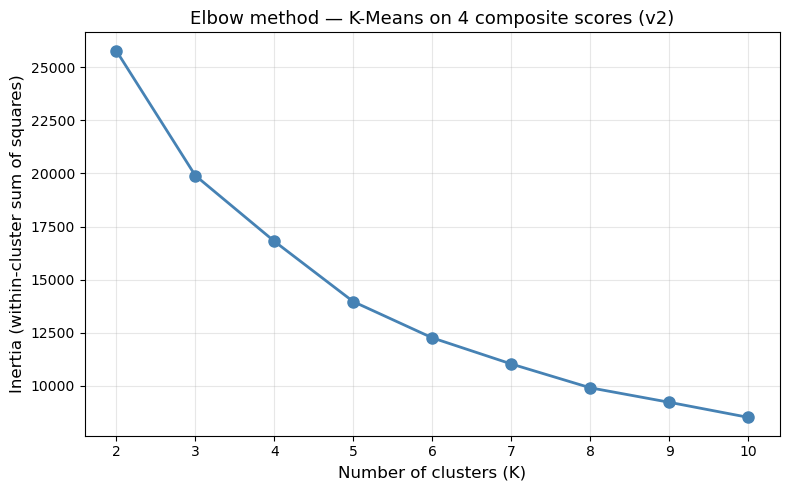


Fitting K-Means with K=4
Cluster counts:
cluster
0    3010
1    1507
2    6458
3    2839


In [6]:
K_range = range(2, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Number of clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (within-cluster sum of squares)', fontsize=12)
ax.set_title('Elbow method — K-Means on 4 composite scores (v2)', fontsize=13)
ax.set_xticks(list(K_range))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Fit final model — adjust K based on the elbow above
K = 4
print(f"\nFitting K-Means with K={K}")
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
combined['cluster'] = kmeans.fit_predict(X_scaled)
print(f"Cluster counts:")
print(combined['cluster'].value_counts().sort_index().to_string())

## 7. Cluster profiles

The mean of each composite score per cluster gives the profile. Because all four scores are on the same 0–1 scale, they can be compared directly without further normalisation.

Breach rate is shown as a **post-hoc descriptor** — it was not used in clustering. This is the key methodological improvement over v1: the clusters reflect cyber security *behaviour*, and breach outcome is then observed, not imposed.

In [7]:
profile = combined.groupby('cluster')[COMPOSITE_FEATURES + ['breached']].mean().round(3)
profile['n'] = combined.groupby('cluster').size()

print("Cluster profiles (mean composite scores + post-hoc breach rate):")
print(profile.to_string())

print("\n--- Suggested archetype labels (inspect profile to confirm) ---")
print("Cluster with highest scores across all dimensions → Security Leaders")
print("Cluster with high policy/manage but lower controls → Compliance Driven")
print("Cluster with low governance, moderate controls   → Reactive")
print("Cluster with low scores across all dimensions    → Low Awareness")

Cluster profiles (mean composite scores + post-hoc breach rate):
         priority_score  manage_score  policy_score  controls_score  breached     n
cluster                                                                            
0                 1.000         0.518         0.766           0.849     0.630  3010
1                 0.241         0.189         0.019           0.276     0.297  1507
2                 0.811         0.217         0.025           0.381     0.426  6458
3                 0.631         0.501         0.743           0.770     0.620  2839

--- Suggested archetype labels (inspect profile to confirm) ---
Cluster with highest scores across all dimensions → Security Leaders
Cluster with high policy/manage but lower controls → Compliance Driven
Cluster with low governance, moderate controls   → Reactive
Cluster with low scores across all dimensions    → Low Awareness


## 8. Profile heatmap

Heatmap of mean composite scores per cluster. Rows = clusters, columns = four dimensions. With only four columns this is clean and readable — a significant improvement over the 26-column v1 heatmap.

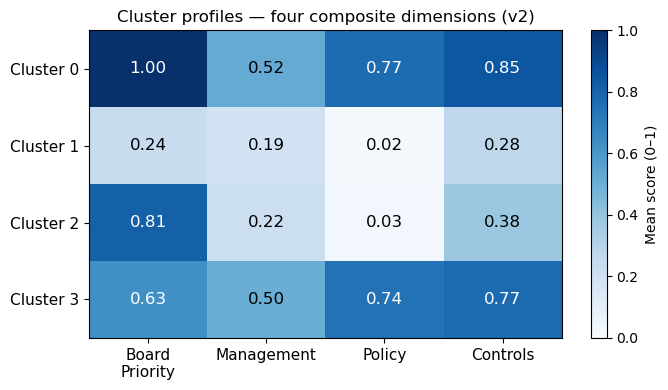

In [8]:
profile_scores = profile[COMPOSITE_FEATURES]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(profile_scores.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(COMPOSITE_FEATURES)))
ax.set_xticklabels(['Board\nPriority', 'Management', 'Policy', 'Controls'], fontsize=11)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {i}' for i in range(K)], fontsize=11)

for i in range(K):
    for j in range(len(COMPOSITE_FEATURES)):
        val = profile_scores.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=12, color='white' if val > 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Mean score (0–1)')
ax.set_title('Cluster profiles — four composite dimensions (v2)', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Radar chart

Radar (spider) chart showing each cluster's profile across the four dimensions. All four axes are 0–1, so the chart is directly comparable across dimensions.

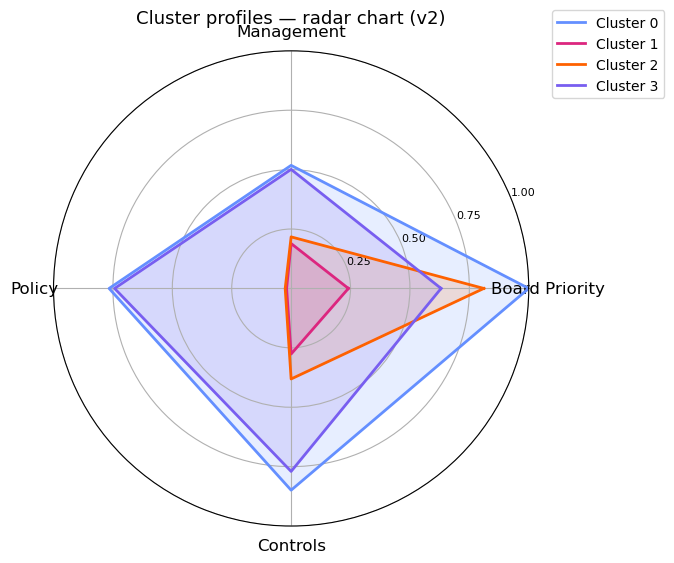

In [9]:
labels   = ['Board Priority', 'Management', 'Policy', 'Controls']
n_labels = len(labels)
angles   = np.linspace(0, 2 * np.pi, n_labels, endpoint=False).tolist()
angles  += angles[:1]  # close the polygon

colors = ['#648FFF', '#DC267F', '#FE6100', '#785EF0']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(profile_scores.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Cluster {idx}')
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Cluster profiles — radar chart (v2)', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Breach rate as post-hoc descriptor

Breach outcome was **not** used in clustering. It is now examined as an outcome associated with each cluster — this is the correct analytical sequence: define organisation types by behaviour, then observe whether breach rates differ.

A clear gradient from low to high breach rate across clusters would support the hypothesis that governance and control maturity is associated with lower breach risk.

Breach rate by cluster (post-hoc — not used in clustering):
         breach_rate     n  breach_pct
cluster                               
0              0.630  3009        63.0
1              0.297  1507        29.7
2              0.426  6458        42.6
3              0.620  2839        62.0


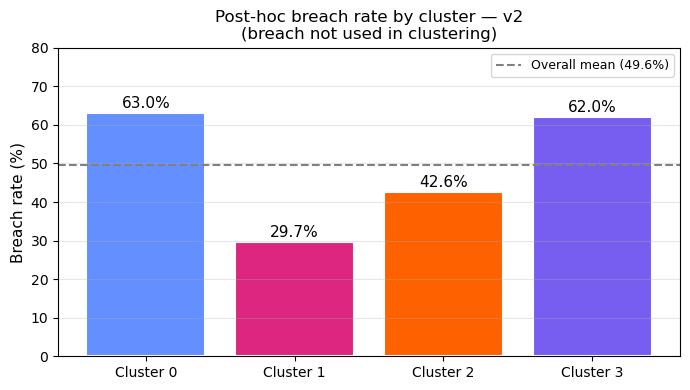

In [10]:
breach_by_cluster = combined.groupby('cluster')['breached'].agg(['mean', 'count']).round(3)
breach_by_cluster.columns = ['breach_rate', 'n']
breach_by_cluster['breach_pct'] = (breach_by_cluster['breach_rate'] * 100).round(1)

print("Breach rate by cluster (post-hoc — not used in clustering):")
print(breach_by_cluster.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [f'Cluster {i}' for i in range(K)],
    breach_by_cluster['breach_pct'],
    color=colors[:K],
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, breach_by_cluster['breach_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Breach rate (%)', fontsize=11)
ax.set_title('Post-hoc breach rate by cluster — v2\n(breach not used in clustering)', fontsize=12)
ax.set_ylim(0, 80)
ax.axhline(combined['breached'].mean() * 100, color='grey', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({combined["breached"].mean()*100:.1f}%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_breach_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cluster share by year

How has the distribution of organisations across clusters changed over time? A shift from low-maturity clusters towards high-maturity clusters would indicate improving population-level cyber security behaviour.

Note: CSBS is repeated cross-sectional data — different respondents each year. This shows population-level distribution, not individual trajectories.

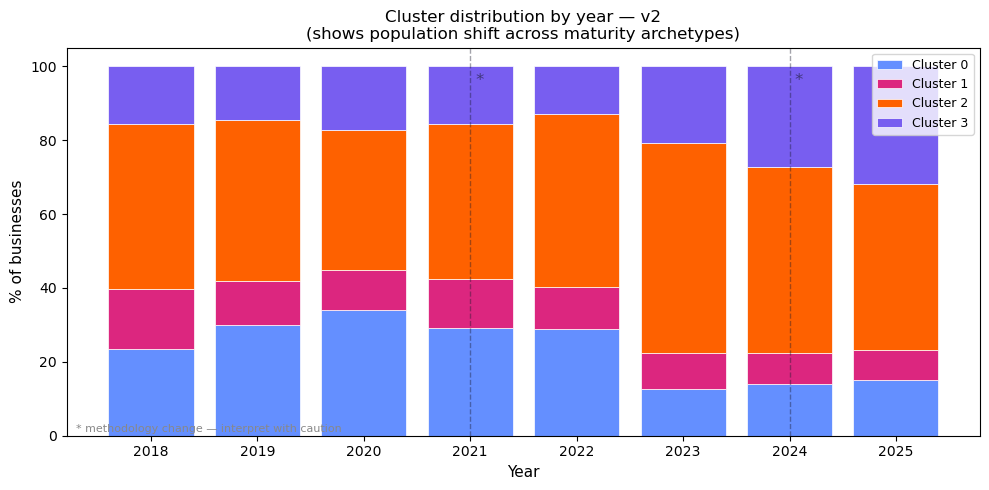

In [11]:
share = combined.groupby(['year', 'cluster']).size().unstack(fill_value=0)
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(share_pct))

for i, col in enumerate(share_pct.columns):
    ax.bar(share_pct.index, share_pct[col], bottom=bottom,
           color=colors[i], label=f'Cluster {col}', edgecolor='white', linewidth=0.5)
    bottom += share_pct[col].values

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('% of businesses', fontsize=11)
ax.set_title('Cluster distribution by year — v2\n(shows population shift across maturity archetypes)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(share_pct.index)

# Mark methodology changes
for year_mark in [2021, 2024]:
    ax.axvline(year_mark, color='#1A1A2E', linestyle='--', linewidth=1, alpha=0.4)
    ax.text(year_mark + 0.05, 95, '*', fontsize=12, color='#1A1A2E', alpha=0.6)

ax.text(0.01, 0.01, '* methodology change — interpret with caution',
        transform=ax.transAxes, fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_cluster_share.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. PCA scatter — 2D projection

With only four composite features, PCA collapses to two components for visualisation. The scatter shows how well-separated the clusters are in reduced space. With fewer, more distinct features than v1, cluster separation may be cleaner.

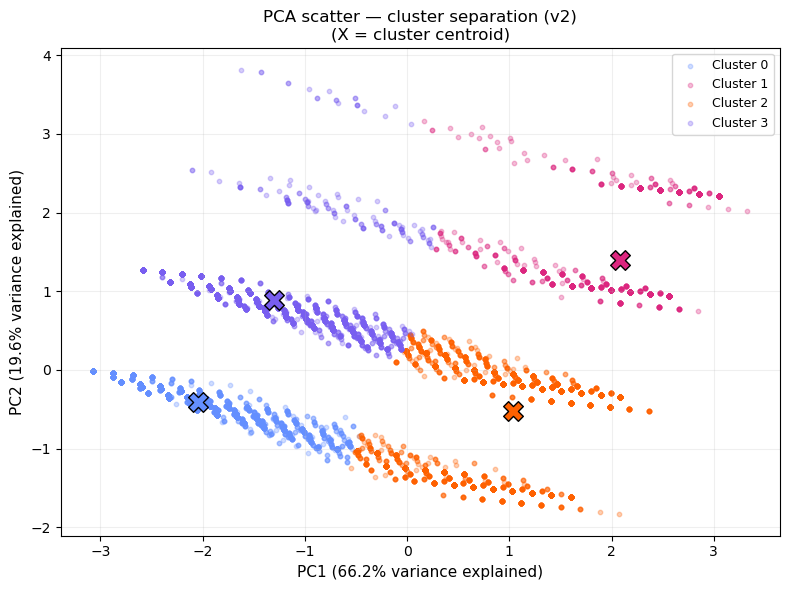


Variance explained: PC1=66.2%, PC2=19.6%
Total variance captured: 85.8%


In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(K):
    mask = combined['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[i], alpha=0.3, s=10, label=f'Cluster {i}')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, centroid in enumerate(centroids_pca):
    ax.scatter(*centroid, color=colors[i], s=200, marker='X',
               edgecolors='black', linewidths=1, zorder=5)

var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('PCA scatter — cluster separation (v2)\n(X = cluster centroid)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariance explained: PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}%")
print(f"Total variance captured: {sum(var_explained)*100:.1f}%")

## 13. Org size breakdown by cluster

Org size (`sizeb`) is a metadata variable — not used in clustering. Examining the size composition of each cluster shows whether the archetypes correspond to size bands, or whether maturity varies within size bands (which would be the more interesting finding).

Org size composition by cluster (%):
sizeb    Micro  Small  Medium  Large
cluster                             
0         27.7   23.5    23.6   25.2
1         75.2   17.3     5.4    2.1
2         64.6   20.4     9.6    5.5
3         30.3   26.5    26.0   17.2


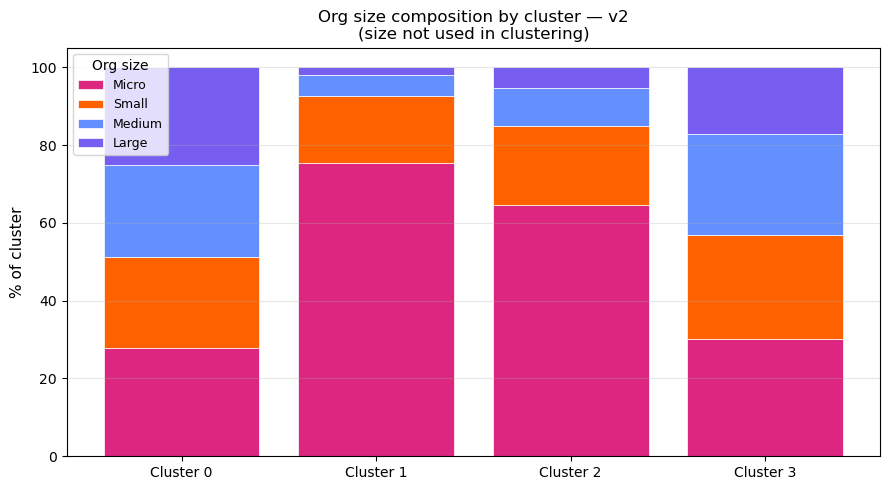

In [13]:
size_labels = {1: 'Micro', 2: 'Small', 3: 'Medium', 4: 'Large'}
size_colors = ['#DC267F', '#FE6100', '#648FFF', '#785EF0']

size_crosstab = combined.groupby(['cluster', 'sizeb']).size().unstack(fill_value=0)
size_crosstab = size_crosstab.rename(columns=size_labels)
size_pct = size_crosstab.div(size_crosstab.sum(axis=1), axis=0) * 100

print("Org size composition by cluster (%):")
print(size_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(K)

for i, col in enumerate(size_pct.columns):
    ax.bar([f'Cluster {c}' for c in range(K)], size_pct[col],
           bottom=bottom, color=size_colors[i], label=col,
           edgecolor='white', linewidth=0.5)
    bottom += size_pct[col].values

ax.set_ylabel('% of cluster', fontsize=11)
ax.set_title('Org size composition by cluster — v2\n(size not used in clustering)', fontsize=12)
ax.legend(title='Org size', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_v2_size_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Interpretation and academic notes

### Key improvements over v1

| Issue in v1 | Resolution in v2 |
|---|---|
| `breached` included in cluster features (circular) | Removed — breach is now a post-hoc outcome descriptor |
| `step1–step10` as 10 separate variables (over-weighted) | Collapsed to single `controls_score` (proportion 0–1) |
| `policy8`, `policy9` at 47% availability (heavy imputation) | Excluded — `policy_score` uses only `policy1–5` (100% available) |
| 26-column heatmap (hard to read) | 4-column heatmap (clean and interpretable) |

### Academic framing

> *K-Means clustering was applied to four composite scores — board priority, management activity, policy coverage, and technical controls adoption — derived from the stable 172-variable longitudinal core across all 8 CSBS waves (2018–2025). Breach outcome was excluded from clustering inputs and examined post-hoc as an outcome descriptor. This design avoids circularity, reduces feature redundancy, and produces clusters that represent theoretically coherent cyber security behaviour archetypes.*

### Limitations

- **Repeated cross-sectional data** — different respondents each wave. Cluster distribution over time reflects population-level shifts, not individual trajectories.
- **Unweighted** — the `weight` variable is not applied. Weighted clustering is a possible extension.
- **Self-reported data** — both governance behaviours and breach outcomes are self-reported. Under-reporting is likely.
- **`priority_score` — 25% imputed** — DK responses to Q9 are median-imputed. This is the remaining data quality concern.
- **K=4 is a choice** — the archetype labels should be assigned by inspecting the actual cluster profiles, not assumed in advance.